In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [7]:
np.random.seed(10)

data = {
    'Age': np.random.randint(18, 65, 50),
    'AnnualIncome': np.random.randint(20000, 100000, 50),
    'SpendingScore': np.random.randint(1, 100, 50)
}

df = pd.DataFrame(data)
df.head()

,Age,AnnualIncome,SpendingScore
0,27,64496,18
1,54,25191,33
2,33,72568,82
3,18,50091,81
4,46,87217,42


In [8]:
X = df[['Age', 'AnnualIncome', 'SpendingScore']]

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
kmeans = KMeans(n_clusters=3, random_state=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()

,Age,AnnualIncome,SpendingScore,Cluster
0,27,64496,18,2
1,54,25191,33,1
2,33,72568,82,0
3,18,50091,81,0
4,46,87217,42,2


In [11]:
sil_score = silhouette_score(X_scaled, clusters)
db_score = davies_bouldin_score(X_scaled, clusters)
ch_score = calinski_harabasz_score(X_scaled, clusters)

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_score)
print("Calinski-Harabasz Score:", ch_score)

Silhouette Score: 0.352560018483796
Davies-Bouldin Index: 1.0307632903470652
Calinski-Harabasz Score: 24.949516282887483


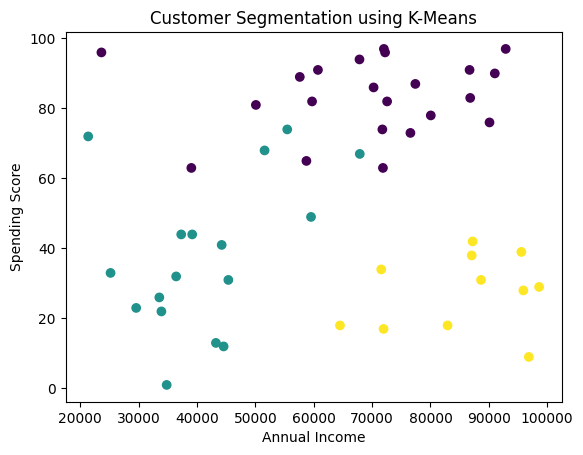

In [12]:
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()